In [1]:
import json
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [2]:
with open("movie_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Loaded {len(df)} movies")
df.head()

Loaded 970 movies


,imdb_url,title,year,runtime,genre,rating,votes,plot
0,https://www.imdb.com/title/tt7229666/,Chhakka Panja 2,2017,138 min,"Comedy, Drama",6.6,290,Chhakka Panja 2 continues with the new story o...
1,https://www.imdb.com/title/tt8393764/,Chhakka Panja 3,2018,145 min,Comedy,6.3,96,When she learns about the worst condition of t...
2,https://www.imdb.com/title/tt7672868/,Intu Mintu Londonma,2018,120 min,Romance,7.3,71,When Ishan (Dhiraj Magar) and Meera (Samragyee...
3,https://www.imdb.com/title/tt10942220/,Kabaddi Kabaddi Kabaddi,2019,115 min,"Comedy, Drama, Romance",8.6,9,A heartbroken man falls in love with a woman w...
4,https://www.imdb.com/title/tt8387542/,Captain,2019,135 min,"Drama, Sport",3.2,46,Father's dedication to guiding his son to beco...


In [3]:
for col in df.columns:
    empty_mask = df[col].isna() | df[col].astype(str).str.strip().eq("")
    if col == "plot":
        empty_mask = empty_mask | df[col].astype(str).str.strip().eq("Add a Plot")
    print(f"{col:12s}: {empty_mask.sum()} missing/empty")

imdb_url    : 0 missing/empty
title       : 0 missing/empty
year        : 27 missing/empty
runtime     : 0 missing/empty
genre       : 0 missing/empty
rating      : 0 missing/empty
votes       : 0 missing/empty
plot        : 3 missing/empty


In [4]:
df["plot"] = df["plot"].astype(str).str.strip()
df.loc[df["plot"].isin(["Add a Plot", "nan", ""]), "plot"] = ""

df["genre"] = df["genre"].astype(str).str.strip()
df.loc[df["genre"].isin(["nan", ""]), "genre"] = "Unknown"

df["year"] = df["year"].astype(str).str.strip()
df.loc[df["year"].isin(["nan", ""]), "year"] = "Unknown"

# Drop rows with zero content signal (no genre AND no plot)
before = len(df)
df = df[~((df["genre"] == "Unknown") & (df["plot"] == ""))].reset_index(drop=True)
print(f"Dropped {before - len(df)} movies. Remaining: {len(df)}")

Dropped 0 movies. Remaining: 970


In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s,.]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["plot_clean"] = df["plot"].apply(clean_text)
df[["plot", "plot_clean"]].iloc[0]

plot          Chhakka Panja 2 continues with the new story o...
plot_clean    chhakka panja 2 continues with the new story o...
Name: 0, dtype: object

In [6]:
def clean_genre(genre):
    parts = [g.strip().title() for g in str(genre).split(",")]
    return ", ".join(parts)

df["genre_clean"] = df["genre"].apply(clean_genre)
df["genre_clean"].unique()[:15]

array(['Comedy, Drama', 'Comedy', 'Romance', 'Comedy, Drama, Romance',
       'Drama, Sport', 'Drama', 'Drama, Romance',
       'Documentary, Adventure, Drama', 'Drama, History',
       'Adventure, Drama', 'Action, Drama, History',
       'Comedy, Drama, Family', 'Action, Thriller', 'Action, Drama',
       'Short, Drama'], dtype=object)

In [7]:
df["combined_features"] = (
    ("Genre: " + df["genre_clean"] + ". ") * 3 +
    "Plot: " + df["plot_clean"]
).str.strip()

In [8]:
model = SentenceTransformer("all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [9]:
embeddings = model.encode(
    df["combined_features"].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
embeddings.shape

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

(970, 384)

In [10]:
sim_matrix = cosine_similarity(embeddings)
sim_matrix.shape

(970, 970)

In [11]:
title_to_index = {
    title.strip().lower(): idx
    for idx, title in enumerate(df["title"])
}


In [12]:
def recommend(title, top_n=5):
    key = title.strip().lower()
    if key not in title_to_index:
        matches = [t for t in title_to_index if key in t]
        if not matches:
            return f"'{title}' not found. Use search_movies() first."
        key = matches[0]
    idx = title_to_index[key]
    sims = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)
    sims = [s for s in sims if s[0] != idx][:top_n]
    result = df.iloc[[i for i, _ in sims]][["title", "genre", "plot"]].copy()
    result["similarity"] = [round(float(s), 4) for _, s in sims]
    return result.reset_index(drop=True)

In [25]:
recommend("Loot", top_n=5)

,title,genre,plot,similarity
0,Sherbahadur,"Drama, Thriller",Three people rob the houses of rich people whe...,0.7959
1,Antim Sanskar: The Last Ritual,"Action, Mystery, Crime, Thriller",A gifted but troubled detective investigates t...,0.7957
2,Mango Pickle,"Crime, Drama, Thriller",A series of events land a timid college kid in...,0.7945
3,The Winner,Thriller,THE WINNER captures the untold stories of Orga...,0.7840
4,Superhit,Thriller,A suspenseful thriller following an ambitious ...,0.7834


In [14]:
def search_movies(query, limit=15):
    query = query.strip().lower()
    matches = df[df["title"].str.lower().str.contains(query, na=False)]
    return matches[["title", "genre", "plot"]].head(limit).reset_index(drop=True)

search_movies("panja")

,title,genre,plot
0,Chhakka Panja 2,"Comedy, Drama",Chhakka Panja 2 continues with the new story o...
1,Chhakka Panja 3,Comedy,When she learns about the worst condition of t...
2,Chhakka Panja,"Comedy, Drama, Family","Story of five friends Raja (Deepak Raj Giri), ..."
3,Chhakka Panja 4,Comedy,Nirvaya Singh is currently the head of one of ...


In [15]:
search_movies("Kabaddi")

,title,genre,plot
0,Kabaddi Kabaddi Kabaddi,"Comedy, Drama, Romance",A heartbroken man falls in love with a woman w...
1,Kabaddi Kabaddi,"Comedy, Drama",Kaji dreams of marrying Maiya but things go wr...
2,Kabaddi,"Comedy, Drama, Romance",Kazi a young aimless man dreams of marrying Ma...
3,Kabaddi 4: The Final Match,"Comedy, Drama","After the events of Kabaddi 3, Kaji no longer ..."


In [16]:
with open("movie_embeddings.pkl", "wb") as f:
    pickle.dump({
        "df": df,
        "embeddings": embeddings,
        "sim_matrix": sim_matrix,
        "title_to_index": title_to_index,
    }, f)
print("Saved.")

Saved.


In [17]:
def precision_recall_at_k(k=5, sample_size=100, seed=42):
    rng = np.random.default_rng(seed)
    n = len(df)
    sample_idxs = rng.choice(n, size=min(sample_size, n), replace=False)
    genre_sets = df["genre_clean"].apply(lambda g: set(x.strip().lower() for x in g.split(",")))
    precisions, recalls = [], []
    for idx in sample_idxs:
        query_genres = genre_sets.iloc[idx]
        relevant = {j for j in range(n) if j != idx and genre_sets.iloc[j] & query_genres}
        if not relevant:
            continue
        sims = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)
        top_k = [i for i, _ in sims if i != idx][:k]
        hits = len(set(top_k) & relevant)
        precisions.append(hits / k)
        recalls.append(hits / min(len(relevant), k))
    print(f"Precision@{k}: {np.mean(precisions):.4f}")
    print(f"Recall@{k}:    {np.mean(recalls):.4f}")

precision_recall_at_k(k=5)

Precision@5: 0.9237
Recall@5:    0.9361


In [18]:
# Inspect: compare two specific movies' plots and their computed similarity
movie_a = "Chhakka Panja 2"
movie_b = "Chhakka Panja"

idx_a = title_to_index[movie_a.lower()]
idx_b = title_to_index[movie_b.lower()]

print("Movie A:", df.iloc[idx_a]["title"], "-", df.iloc[idx_a]["plot"][:150])
print()
print("Movie B:", df.iloc[idx_b]["title"], "-", df.iloc[idx_b]["plot"][:150])
print()
print("Cosine similarity:", sim_matrix[idx_a][idx_b])

Movie A: Chhakka Panja 2 - Chhakka Panja 2 continues with the new story of Raja and his friend at the village.

Movie B: Chhakka Panja - Story of five friends Raja (Deepak Raj Giri), Saraswoti (Jeetu Nepal), Magne (Kedar Ghimire) and Buddhi (Buddhi Tamang). Raja is rich but illiterate a

Cosine similarity: 0.7356442


A Mero Hajur 2 vs Kusume Rumal: 0.8939
Darpan Chhaya vs Classic: 0.8797
Prasad vs Kafal Pakyo: 0.8770


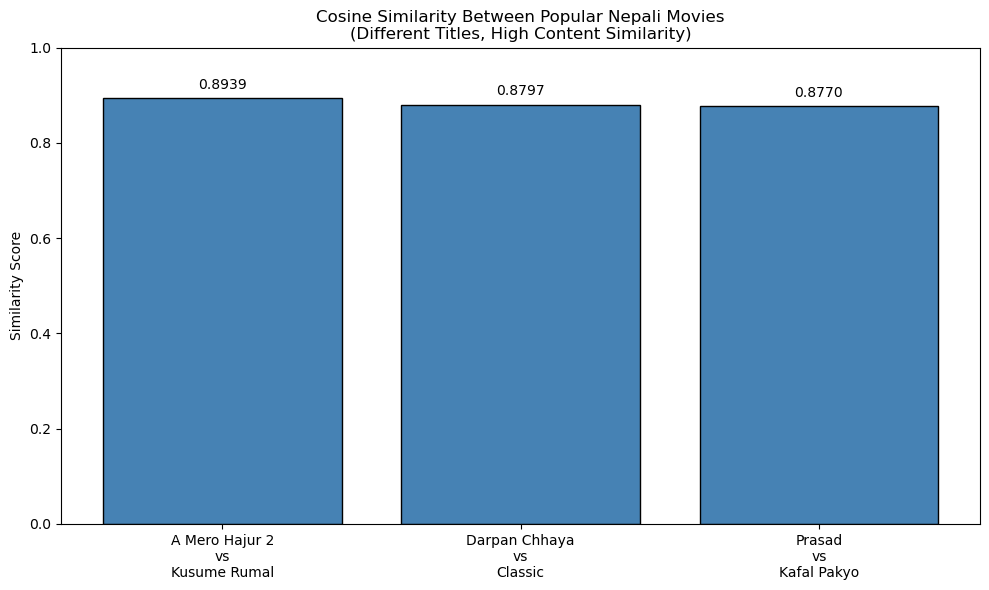

In [21]:
import matplotlib.pyplot as plt

pairs = [
    ("A Mero Hajur 2", "Kusume Rumal"),
    ("Darpan Chhaya", "Classic"),
    ("Prasad", "Kafal Pakyo"),
]

pair_labels = []
pair_scores = []

for movie_a, movie_b in pairs:
    idx_a = title_to_index[movie_a.lower()]
    idx_b = title_to_index[movie_b.lower()]
    score = sim_matrix[idx_a][idx_b]
    pair_labels.append(f"{movie_a}\nvs\n{movie_b}")
    pair_scores.append(round(score, 4))
    print(f"{movie_a} vs {movie_b}: {score:.4f}")

plt.figure(figsize=(10, 6))
bars = plt.bar(pair_labels, pair_scores, color="steelblue", edgecolor="black")
plt.ylabel("Similarity Score")
plt.title("Cosine Similarity Between Popular Nepali Movies\n(Different Titles, High Content Similarity)")
plt.ylim(0, 1)
for bar, score in zip(bars, pair_scores):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f"{score:.4f}", ha="center")
plt.tight_layout()
plt.show()